# Problem 1

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import pairwise_distances

In [10]:
# 加载数据
data = pd.read_csv('watermelon_3.csv',encoding='gbk')

# 假设最后一列是目标标签，其他列是特征
X = data.iloc[:, :-1]  # 特征
y = data.iloc[:, -1]   # 标签

# 将数据拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
def compute_distances(X):
    # 计算数据集中的所有样本之间的欧式距离
    return pairwise_distances(X, metric='euclidean')

# 计算训练数据中的所有距离
distances = compute_distances(X_train)


In [73]:
def find_nearest_neighbors(distances, y_train, n_neighbors=10):
    n_samples = len(y_train)
    neighbors = []
    # print(y_train[3])
    for i in range(n_samples):
        # 获取距离当前样本最近的n_neighbors个样本
        sorted_indices = np.argsort(distances[i])
        # print(sorted_indices)
        # print(y_train)
        # print("y_train.index[]",y_train.index[sorted_indices])
        # 过滤掉第一个（自己）并获取正近邻和负近邻
        pos_neighbor = None
        neg_neighbor = None
        # 获取正近邻（标签相同）和负近邻（标签不同）
        for idx in sorted_indices[1:n_neighbors+1]:
            # idx = int(idx)
            # print(f"idx:{idx},sorted_indices[0]:{sorted_indices[0]}")
            if y_train.iloc[idx] == y_train.iloc[sorted_indices[0]]:  # 正近邻（标签相同）
                pos_neighbor = idx
            else:  # 负近邻（标签不同）
                neg_neighbor = idx
            if pos_neighbor is not None and neg_neighbor is not None:
                break
        neighbors.append((pos_neighbor, neg_neighbor))
    return neighbors

# 获取每个样本的正近邻和负近邻
neighbors = find_nearest_neighbors(distances, y_train)
print(neighbors)

[(np.int64(2), np.int64(8)), (np.int64(2), np.int64(8)), (np.int64(5), np.int64(8)), (np.int64(5), np.int64(8)), (np.int64(8), np.int64(2)), (np.int64(2), np.int64(8)), (np.int64(2), np.int64(8)), (np.int64(8), np.int64(2)), (np.int64(12), np.int64(2)), (np.int64(3), np.int64(8)), (np.int64(6), np.int64(8)), (np.int64(8), np.int64(2)), (np.int64(7), np.int64(2))]


In [87]:
def reliefF(X_train, y_train, neighbors, n_features_to_select=10):
    n_samples, n_features = X_train.shape
    feature_importance = np.zeros(n_features)
    
    # 对每个实例进行处理
    for i in range(n_samples):
        pos_neighbor, neg_neighbor = neighbors[i]
        # print(f"pos_neighbors:{pos_neighbor},neg_neighbors:{neg_neighbor}")
        # print(X_train.shape)
        # 计算当前样本与正近邻和负近邻的差异
        for j in range(n_features):
            # 当前样本的特征值
            # print(X_train.iloc[i].iloc[j])
            # 获取特征 j 的最大值和最小值
            feature_min = X_train.iloc[:, j].min()
            feature_max = X_train.iloc[:, j].max()
            feature_range = feature_max - feature_min
            xi = X_train.iloc[i, j]
            
            # 计算正近邻和负近邻的差异
            pos_diff = np.abs(X_train.iloc[int(pos_neighbor), j] - xi)
            neg_diff = np.abs(X_train.iloc[int(neg_neighbor), j] - xi)
            
            # 计算特征贡献并更新特征重要性
            feature_importance[j] += (pos_diff - neg_diff) / (n_samples * feature_range)
            
    return feature_importance

importance_scores = reliefF(X_train, y_train, neighbors)
# 输出每个特征的重要性
print(f"Feature importance scores: {importance_scores}")


Feature importance scores: [-0.05494505  0.03846154  0.15384615 -0.15384615 -0.15384615  0.15384615
  0.23076923  0.1512605  -0.06463505]


In [89]:
def select_top_features(importance_scores, n_features_to_select=5):
    # 获取特征的重要性排序
    top_indices = np.argsort(np.abs(importance_scores))[::-1][:n_features_to_select]
    return top_indices

# 选择最重要的特征
top_features = select_top_features(importance_scores, n_features_to_select=5)
print(f"Top selected features: {top_features}, name:{X_train.columns[top_features]}")

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 提取选定的特征
X_train_selected = X_train.iloc[:, top_features]
X_test_selected = X_test.iloc[:, top_features]

# 训练SVM分类器
svm_model = SVC(kernel='linear')  # 线性SVM
svm_model.fit(X_train_selected, y_train)

# 在测试集上进行预测
y_pred = svm_model.predict(X_test_selected)

# # 打印分类报告和准确度
# from sklearn.metrics import classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

Top selected features: [6 5 4 3 2], name:Index(['触感', '脐部', '纹理', '敲声', '根蒂'], dtype='object')
Accuracy: 1.0


# Problem 3

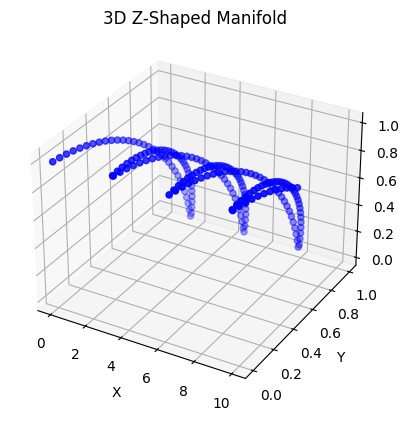

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 生成t的值
t = np.linspace(0, 10, 200)

# 定义Z型流形的三维坐标
x = t
y = np.abs(np.sin(t))
z = np.abs(np.cos(t))

# 创建三维坐标数据
data_3d = np.column_stack((x, y, z))

# 绘制三维数据点
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_3d[:, 0], data_3d[:, 1], data_3d[:, 2], c='b', marker='o')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D Z-Shaped Manifold")
plt.show()


In [92]:
from sklearn.metrics.pairwise import pairwise_distances

# 计算所有数据点之间的欧式距离
distances = pairwise_distances(data_3d, metric='euclidean')

# 设置邻接矩阵，选择邻近的k个点来构建图（k是你选择的参数）
k = 10  # 选择适当的邻居数量
adjacency_matrix = np.zeros_like(distances)

for i in range(len(distances)):
    # 找到当前点的k个最近邻
    nearest_neighbors = np.argsort(distances[i])[:k+1]  # 包括自己在内
    adjacency_matrix[i, nearest_neighbors] = distances[i, nearest_neighbors]
    adjacency_matrix[nearest_neighbors, i] = distances[i, nearest_neighbors]


In [93]:
import scipy.sparse
import scipy.sparse.csgraph as csgraph

# 将邻接矩阵转换为稀疏矩阵
adjacency_matrix_sparse = scipy.sparse.csgraph.csgraph_from_dense(adjacency_matrix)

# 计算最短路径
shortest_paths = csgraph.shortest_path(adjacency_matrix_sparse, directed=False, return_predecessors=False)


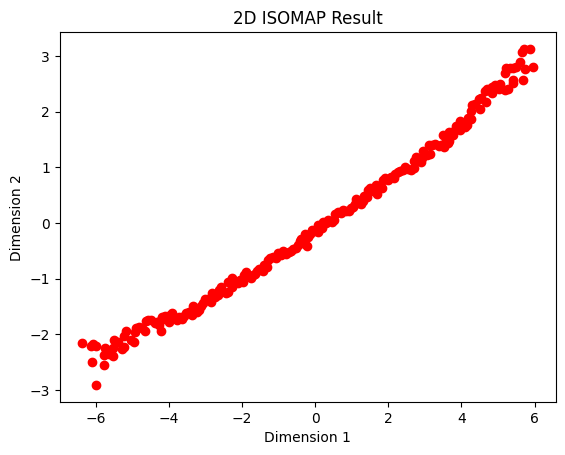

In [94]:
from sklearn.manifold import MDS

# 使用经典MDS进行降维
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
data_2d = mds.fit_transform(shortest_paths)

# 绘制降维后的二维数据点
plt.scatter(data_2d[:, 0], data_2d[:, 1], c='r', marker='o')
plt.title("2D ISOMAP Result")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
